# Pulsar Net — Pulsar Classification

> Pulsars are rare neutron stars that emit detectable radio signals. Radio surveys produce thousands of pulsar candidates, most of which are false positives caused by radio-frequency interference (RFI) or noise. This notebook builds a machine learning classifier to distinguish **real pulsars** from **non-pulsars** using statistical features extracted from their signals.

**Dataset:** [HTRU_2 on Kaggle](https://www.kaggle.com/datasets/charitarth/pulsar-dataset-htru2), originally from [Lyon et al., University of Manchester](https://archive.ics.uci.edu/ml/datasets/HTRU2).

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, fbeta_score, RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import shap
import joblib

In [113]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel("actual")
    plt.xlabel("predicted")
    plt.show()

## load data

In [114]:
column_names = ["mean_profile", "std_profile", "kurtosis_profile", "skewness_profile",
                "mean_dmsnr", "std_dmsnr", "kurtosis_dmsnr", "skewness_dmsnr", "class"]

data = pd.read_csv("HTRU_2.csv", names=column_names)
data.head()

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dmsnr,std_dmsnr,kurtosis_dmsnr,skewness_dmsnr,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


## class balance check

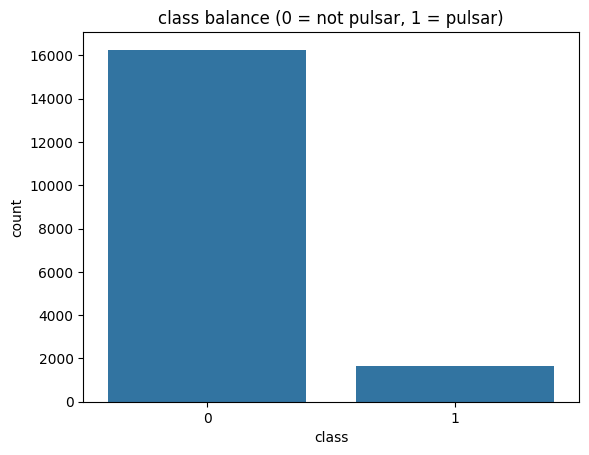

In [115]:
data["class"].value_counts(normalize=True)
sns.countplot(data=data, x="class")
plt.title("class balance (0 = not pulsar, 1 = pulsar)")
plt.show()

## feature engineering

In [116]:
# core physics ratios
data["snr_robustness"] = data["mean_profile"] / (data["std_dmsnr"] + 1e-9)
data["peak_to_noise"] = data["mean_profile"] / (data["skewness_dmsnr"] + 1e-9)
data["sharpness_index"] = data["kurtosis_profile"] / (data["std_profile"] + 1e-9)
data["ism_factor"] = data["mean_dmsnr"] * data["skewness_dmsnr"]

# advanced signatures
data["pulsar_signature_score"] = data["kurtosis_profile"] * data["sharpness_index"]
data["energy_concentration"] = data["mean_profile"] * data["sharpness_index"]
data["log_dm_skew"] = np.sign(data['skewness_dmsnr']) * np.log1p(data['skewness_dmsnr'].abs())

# log transforms for skewed distributions
skewed_cols = ['kurtosis_profile', "sharpness_index", "pulsar_signature_score"]
for col in skewed_cols:
    data[f"log_{col}"] = np.sign(data[col]) * np.log1p(data[col].abs())

print(f"final data shape: {data.shape}")

final data shape: (17898, 19)


## split

In [117]:
X = data.drop("class", axis=1)
y = data["class"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"train: {X_train.shape[0]}, val: {X_val.shape[0]}, test: {X_test.shape[0]}")

train: 12528, val: 2685, test: 2685


## baseline model: logistic regression

ogistic Regression CV PR-AUC: 0.9289 +/- 0.0116

logistic regression classification report
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2439
           1       0.76      0.92      0.83       246

    accuracy                           0.97      2685
   macro avg       0.87      0.94      0.91      2685
weighted avg       0.97      0.97      0.97      2685



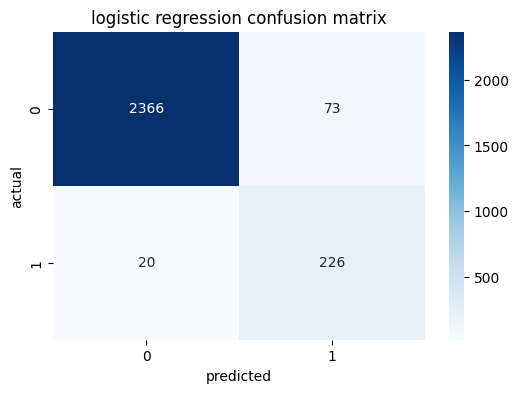

In [118]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_cv_scores = cross_val_score(baseline, X_train_scaled, y_train, cv=skf, scoring="average_precision")
print(f"ogistic Regression CV PR-AUC: {baseline_cv_scores.mean():.4f} +/- {baseline_cv_scores.std():.4f}")

baseline.fit(X_train_scaled, y_train)
y_pred_baseline = baseline.predict(X_test_scaled)
print("\nlogistic regression classification report")
print(classification_report(y_test, y_pred_baseline, zero_division=0))
plot_cm(y_test, y_pred_baseline, "logistic regression confusion matrix")

## primary model: XGBoost

XGBoost CV PR-AUC: 0.9278 +/- 0.0100

threshold: 0.3550
xgboost classification report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2439
           1       0.84      0.90      0.87       246

    accuracy                           0.98      2685
   macro avg       0.92      0.94      0.93      2685
weighted avg       0.98      0.98      0.98      2685



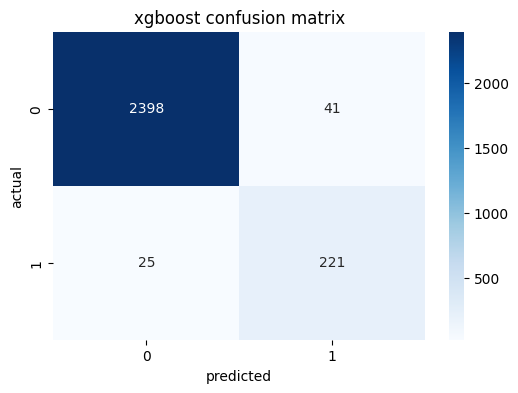

In [119]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="average_precision")
print(f"XGBoost CV PR-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

model.fit(X_train, y_train)

val_probs = model.predict_proba(X_val)[:, 1]
best_score, best_threshold = -1, 0.5
for t in np.linspace(0.1, 0.9, 161):
    preds = (val_probs >= t).astype(int)
    score = fbeta_score(y_val, preds, beta=2, zero_division=0)
    if score > best_score:
        best_score, best_threshold = score, t

test_probs = model.predict_proba(X_test)[:, 1]
y_pred_xgb = (test_probs >= best_threshold).astype(int)

print(f"\nthreshold: {best_threshold:.4f}")
print("xgboost classification report")
print(classification_report(y_test, y_pred_xgb))
plot_cm(y_test, y_pred_xgb, "xgboost confusion matrix")

## evaluation curves

test PR-AUC: 0.9344


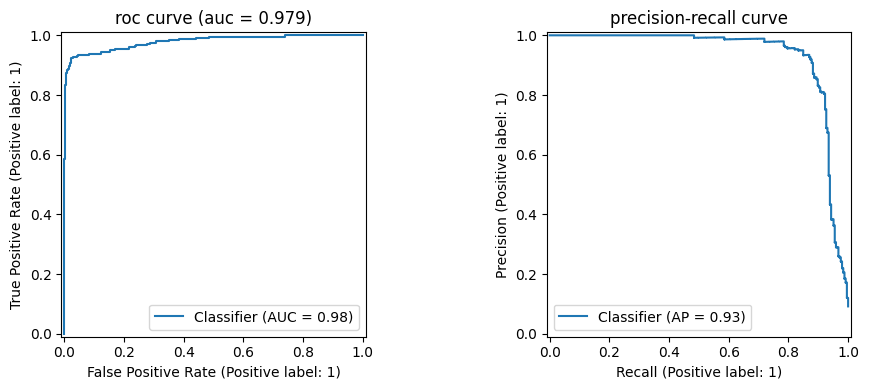

In [120]:
print(f"test PR-AUC: {average_precision_score(y_test, test_probs):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(y_test, test_probs, ax=ax1)
ax1.set_title(f"roc curve (auc = {roc_auc_score(y_test, test_probs):.3f})")
PrecisionRecallDisplay.from_predictions(y_test, test_probs, ax=ax2)
ax2.set_title("precision-recall curve")
plt.tight_layout()
plt.show()

## feature importance

In [121]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp_df = feat_imp.rename("importance").reset_index()
feat_imp_df.columns = ["feature", "importance"]

print("top features (xgboost):")
print(feat_imp_df.head(10).to_string(index=False))

top features (xgboost):
               feature  importance
  log_kurtosis_profile    0.480246
      kurtosis_profile    0.261263
pulsar_signature_score    0.031821
             std_dmsnr    0.024676
   log_sharpness_index    0.023985
       sharpness_index    0.020218
        snr_robustness    0.017865
            ism_factor    0.014980
        kurtosis_dmsnr    0.014803
  energy_concentration    0.014301


## SHAP

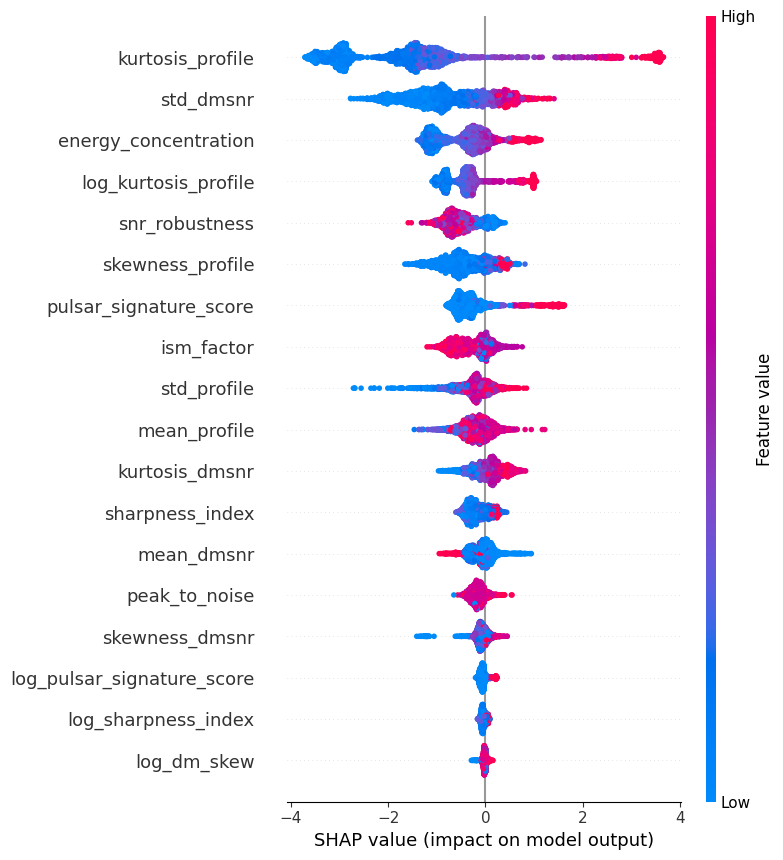

In [122]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(6, 4))
shap.summary_plot(shap_values, X_test, feature_names=X.columns)
plt.show()

## save models

In [123]:
joblib.dump({
    "model": model,
    "threshold": best_threshold,
    "features": list(X.columns)
}, "pulsar_xgb_model.pkl")

print("saved")

saved
